In [1]:
import pandas as pd
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('metadata.csv')

print(f'Data Loaded: {df.shape[0]} rows, {df.shape[1]} cols')

# Only relevent data

df = df.loc[:, ['patient_id', 'img_id', 'diagnostic']]
df.head(3)

Data Loaded: 2103 rows, 28 cols


,patient_id,img_id,diagnostic
0,PAT_1516,PAT_1516_1765_530.png,NEV
1,PAT_46,PAT_46_881_939.png,BCC
2,PAT_1545,PAT_1545_1867_547.png,ACK


In [5]:
# Function to filter valid mask
from skimage import measure

def valid_mask(filename:str) -> bool:
    '''Identifies valid masks given some constraints.'''
    
    valid = False
    path_mask = 'masks/' + filename.replace('.png', '_mask.png')

    try:
        mask = plt.imread(path_mask)
    except FileNotFoundError:
        return np.nan, np.nan

    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)
    sorted_props = sorted(props, key = lambda r: r.area, reverse = True)
    condition = False
    
    if len(props) > 1:
        condition = sorted_props[0].area >= 3*sorted_props[1].area

    if len(props) == 1 or condition:
        valid = True
    
    return valid, len(props)

data = df['img_id'].apply(valid_mask)
df['Valid_mask'] = [x[0] for x in data]
df['number_of_regions'] = [x[1] for x in data]

KeyboardInterrupt: 

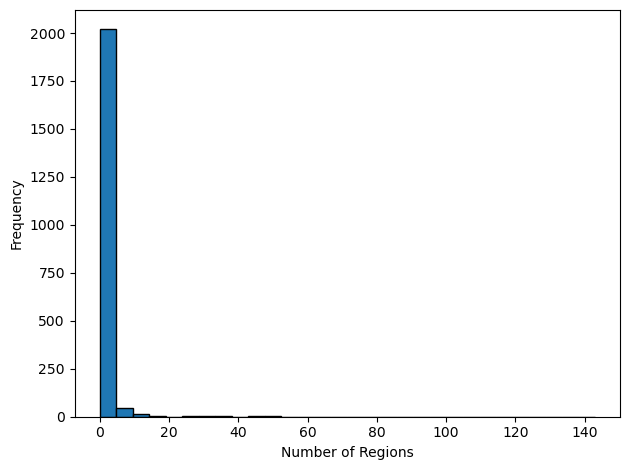

In [136]:
# ======================================
# SPOT OUTLIERS
# ======================================

# VISUAL INSPECTION 

fig = plt.figure()
data = df.number_of_regions
plt.hist(data, bins=30, edgecolor='black')
plt.xlabel('Number of Regions')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [6]:
def outliers(data):
    '''returns outliers of the given data'''
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + IQR

    return data[data > upper_limit]

In [3]:
# Modified mask for more than one regions.
from skimage import measure

def modified_mask(mask):
    
    # convert to binary
    binary_mask = (mask > 0.5).astype(bool)

    # label regions
    labeled = measure.label(binary_mask)
    props = measure.regionprops(labeled)

    # Find region with maximum area
    largest_region = max(props, key = lambda r: r.area)

    # Extract its label
    largest_label = largest_region.label

    # Create mask for that region
    largest_mask = (labeled == largest_label).astype(bool)

    aux_mask = binary_mask.copy()
    aux_mask[largest_mask] = False

    return np.logical_xor(binary_mask, aux_mask)


In [4]:
def show_img_mask(filename):
    '''Displays the image with its corresponding mask'''
    
    path_img = 'imgs/' + filename
    path_mask = 'masks/' + filename.replace('.png', '_mask.png')
    
    try:
        img, mask = plt.imread(path_img), plt.imread(path_mask)
    except FileNotFoundError:
        return

    before_mask = (mask > 0.5).astype(bool)
    after_mask = modified_mask(before_mask)

    fig, ax = plt.subplots(1,3, figsize = (10,8))

    # plot image
    ax[0].imshow(img)
    ax[0].axis('off')
    ax[0].set_title(filename)

    # plot before mask
    ax[1].imshow(before_mask, cmap='grey')
    ax[1].axis('off')
    ax[1].set_title('Before')

    # plot after mask
    ax[2].imshow(after_mask, cmap='grey')
    ax[2].axis('off')
    ax[2].set_title("After")

    plt.tight_layout()
    plt.show()

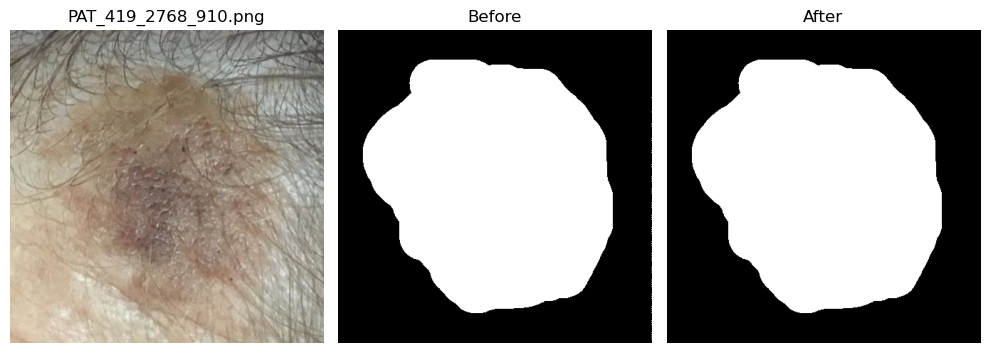

In [5]:
show_img_mask('PAT_419_2768_910.png')